I met a traveller from an antique land,
Who said—“Two vast and trunkless legs of stone
Stand in the desert. . . . Near them, on the sand,
Half sunk a shattered visage lies, whose frown,
And wrinkled lip, and sneer of cold command,
Tell that its sculptor well those passions read
Which yet survive, stamped on these lifeless things,
The hand that mocked them, and the heart that fed;
And on the pedestal, these words appear:

My name is Ozymandias, King of Kings;
Look on my Works, ye Mighty, and despair!"

Nothing beside remains. Round the decay
Of that colossal Wreck, boundless and bare
The lone and level sands stretch far away.

In [600]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import uncertainties
import os

Most of these datasets do not have B field in them and the channel 2 output of transmissivity is not normalized, since it is in arbitrary units we would need a function to normalize them. 

Another thing to note is that fitting to the current readings of the sweep fields would not exactly be feasible because it's all jimble jambled, what I mean to say is that the current readings have high noise such that fitting a lorentzian is not exactly possible, but what we care about is only the peaks and that means we only need to know the value of current near the transmissivity peak and we can include uncertainties within it. 

In [601]:
# Converting the sweep values to b field values:
def add_magnetic_field(filename):
    ItB = (0.6*1e-4)#Teslas
    header_info = pd.read_csv(filename, skiprows=1, nrows=1, header=None)
    timeconst = float(header_info.iloc[0, 4])
    df = pd.read_csv(filename, skiprows=2, usecols=[0, 1, 2], names=["Sequence", "CH1", "CH2"])
    df["Bfield"] = (df["CH1"]*ItB)/10
    df["CH2norm"] = (df["CH2"] - min(df["CH2"]))/(max(df["CH2"])-min(df["CH2"]))
    df["time"] = df["Sequence"]*timeconst
    filename, ext = os.path.splitext(filename)
    new_filename = f"{filename}_B{ext}"
    df.to_csv(new_filename, index=False)
    print("New file:",new_filename) 
    return df

Now using this function to polish the datasets. 

In [602]:
df_25 = add_magnetic_field("linear_zeeman_data/25kHz.csv")
df_50 = add_magnetic_field("linear_zeeman_data/50kHz.csv")
df_75 = add_magnetic_field("linear_zeeman_data/75kHz.csv")
df_100 = add_magnetic_field("linear_zeeman_data/100kHz.csv")
df_125 = add_magnetic_field("linear_zeeman_data/125kHz.csv")
df_150 = add_magnetic_field("linear_zeeman_data/150kHz.csv")
df_175 = add_magnetic_field("linear_zeeman_data/175kHz.csv")
df_195 = add_magnetic_field("linear_zeeman_data/195kHz.csv")
# df_300 = add_magnetic_field("linear_zeeman_data/300kHz_5s.csv")

df = [df_25,df_50,df_75,df_100,df_125,df_150,df_175,df_195]

New file: linear_zeeman_data/25kHz_B.csv
New file: linear_zeeman_data/50kHz_B.csv
New file: linear_zeeman_data/75kHz_B.csv
New file: linear_zeeman_data/100kHz_B.csv
New file: linear_zeeman_data/125kHz_B.csv
New file: linear_zeeman_data/150kHz_B.csv
New file: linear_zeeman_data/175kHz_B.csv
New file: linear_zeeman_data/195kHz_B.csv


Now we gotta fit lorentzians to this data to extract the peak positions along with their uncertainties.
#### Lorentzian fit of the data:

$$f(x;A,x_0,\gamma) = A\cdot\frac{\gamma^2}{\gamma^2+(x-x_0)^2}$$

In [603]:
# All kind of lorentzians that one might need, all in one place!!

def lorentzian(x, y0, a1, c1, w1):
    L1 = a1 / (1 + ((x - c1) / w1)**2)
    return y0 + L1

def duo_lorentzian(x, y0, a1, c1, w1, a2, c2, w2):
    L1 = a1 / (1 + ((x - c1) / w1)**2)
    L2 = a2 / (1 + ((x - c2) / w2)**2)
    return y0 + L1 + L2

def tri_lorentzian(x, y0, a1, c1, w1, a2, c2, w2, a3, c3, w3):
    L1 = a1 / (1 + ((x - c1) / w1)**2)
    L2 = a2 / (1 + ((x - c2) / w2)**2)
    L3 = a3 / (1 + ((x - c3) / w3)**2)
    return y0 + L1 + L2 + L3

def quad_lorentzian(x, y0, a1, c1, w1, a2, c2, w2, a3, c3, w3, a4, c4, w4):
    L1 = a1 / (1 + ((x - c1) / w1)**2)
    L2 = a2 / (1 + ((x - c2) / w2)**2)
    L3 = a3 / (1 + ((x - c3) / w3)**2)
    L4 = a4 / (1 + ((x - c4) / w4)**2)
    return y0 + L1 + L2 + L3 + L4

def hexa_lorentzian(x, y0, a1, c1, w1, a2, c2, w2, a3, c3, w3, a4, c4, w4, a5, c5, w5, a6, c6, w6):
    L1 = a1 / (1 + ((x - c1) / w1)**2)
    L2 = a2 / (1 + ((x - c2) / w2)**2)
    L3 = a3 / (1 + ((x - c3) / w3)**2)
    L4 = a4 / (1 + ((x - c4) / w4)**2)
    L5 = a5 / (1 + ((x - c5) / w5)**2)
    L6 = a6 / (1 + ((x - c6) / w6)**2)
    return y0 + L1 + L2 + L3 + L4 + L5 + L6

So the lorentzian peaks we would get are not the magnetic field values, what we have is time, we need to correlate the time with the magnetic field values and that means we need to write a new function that correlates the time to magnetic field using the current value measured on channel 1. 

In [604]:
# def get_bfield_data(df, center_time, sigma_t, window_size=0.005, result_list=None):
#     ItB = 0.6 * 1e-4
#     bfield_resolution = 0.32 * ItB / 10

#     mask = (df['time'] >= center_time - window_size) & (df['time'] <= center_time + window_size)
#     sub = df.loc[mask]

#     if sub.empty or len(sub) < 3:
#         mean_b = np.nan if sub.empty else sub['Bfield'].mean()
#         unc_b = bfield_resolution
#     else:
#         mean_b = sub['Bfield'].mean()
        
#         # Linear fit to isolate the sweep slope from sensor noise
#         p = np.polyfit(sub['time'], sub['Bfield'], 1)
#         dBdt = p[0]
#         intercept = p[1]
        
#         # Propagated uncertainty from the Lorentzian time center fit
#         unc_propagated = abs(dBdt) * sigma_t
        
#         # Statistical noise (Standard Error of the Mean of the residuals)
#         residuals = sub['Bfield'] - (dBdt * sub['time'] + intercept)
#         std_residuals = np.std(residuals, ddof=2)
#         sem_residuals = std_residuals / np.sqrt(len(sub))
        
#         # Combine all error sources in quadrature
#         unc_b = np.sqrt(unc_propagated**2 + sem_residuals**2 + bfield_resolution**2)

#     if result_list is not None:
#         result_list.append([mean_b, unc_b])
        
#     return mean_b, unc_b

def get_bfield_data(df, center_time, sigma_t, window_size=0.005, result_list=None):
    mask = (df['time'] >= center_time - window_size) & (df['time'] <= center_time + window_size)
    sub = df.loc[mask]

    # Dynamically determine the dataset's resolution (quantization step)
    # This captures the oscilloscope's actual Volts/Div zoom level
    if len(sub) > 1:
        b_diffs = np.abs(np.diff(sub['Bfield']))
        non_zero_diffs = b_diffs[b_diffs > 1e-12] # Filter floating-point zeroes
        
        if len(non_zero_diffs) > 0:
            dynamic_resolution = np.min(non_zero_diffs)
        else:
            dynamic_resolution = 0.32 * (0.6 * 1e-4) / 10 # Fallback
    else:
        dynamic_resolution = 0.32 * (0.6 * 1e-4) / 10 # Fallback

    if sub.empty or len(sub) < 3:
        mean_b = np.nan if sub.empty else sub['Bfield'].mean()
        unc_b = dynamic_resolution
    else:
        mean_b = sub['Bfield'].mean()
        
        # Linear fit to isolate the sweep slope from sensor noise
        p = np.polyfit(sub['time'], sub['Bfield'], 1)
        dBdt = p[0]
        intercept = p[1]
        
        # Propagated uncertainty from the Lorentzian time center fit
        unc_propagated = abs(dBdt) * sigma_t
        
        # Statistical noise (Standard Error of the Mean of the residuals)
        residuals = sub['Bfield'] - (dBdt * sub['time'] + intercept)
        std_residuals = np.std(residuals, ddof=2)
        sem_residuals = std_residuals / np.sqrt(len(sub))
        
        # Combine dynamic instrumental resolution with statistical and propagated errors
        unc_b = np.sqrt(unc_propagated**2 + sem_residuals**2 + dynamic_resolution**2)

    if result_list is not None:
        result_list.append([mean_b, unc_b])
        
    return mean_b, unc_b

In [605]:
def fit_lorentzians(df, p0, num, result_list=None):
    x_data, y_data = df["time"], df["CH2norm"] 
    
    func_map = {
        1: lorentzian,
        2: duo_lorentzian,
        3: tri_lorentzian,
        4: quad_lorentzian,
        6: hexa_lorentzian
    }
    
    if num not in func_map:
        print(f"Unknown lorentzian to fit for num={num}")
        return [], []
        
    fit_func = func_map[num]
    popt, pcov = curve_fit(fit_func, x_data, y_data, p0=p0)
    perr = np.sqrt(np.diag(pcov))
    
    b_means = []
    b_uncs = []
    init_centers = []
    init_amps = []
    
    for i in range(num):
        center_idx = 2 + (i * 3)
        amp_idx = 1 + (i * 3)
        
        center_time = popt[center_idx]
        sigma_t = perr[center_idx]
        
        init_centers.append(p0[center_idx])
        init_amps.append(p0[amp_idx])
        
        # Extracts and stores B-field data for ALL peaks
        mean_b, unc_b = get_bfield_data(df, center_time, sigma_t)
        b_means.append(mean_b)
        b_uncs.append(unc_b)
        
        print(f"Lorentzian peak {i+1}: {center_time:.4f} ± {sigma_t:.4f} | B-field: {mean_b:.4e} ± {unc_b:.4e}")

    plt.figure(figsize=(7, 4))
    plt.plot(x_data, y_data, label='Measured Data', alpha=0.7)
    plt.plot(x_data, fit_func(x_data, *popt), 'r-', linewidth=2, label=f'Fitted {num}-Lorentzian')
    plt.scatter(init_centers, init_amps, color='black', marker='x', label='Initial Guesses', zorder=5)
    plt.xlabel('Time (s)')
    plt.ylabel('CH2norm (Normalized Intensity)')
    plt.title(f'{num}-Lorentzian Multi-Peak Fit')
    plt.grid(True, which='both', linestyle='--', alpha=0.1)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()
    
    if result_list is not None:
        result_list.append(b_means + b_uncs)

    return popt, perr

In [606]:
# List of optimal values with uncertainties
lopt = []
# List of all guesses for the linear regieme
p0guesses = [[1.0,0,2.025,0.018,0.2,2.5,0.023,0.6,2.3,0.022],
             [1.0,0,2.025,0.018,0.2,3.2,0.023,0.6,2.8,0.022],
             [1.0,0,2.025,0.018,0.2,3.6,0.023,0.6,3.1,0.022],
             [1.0,0,2.025,0.018,0.2,4.1,0.023,0.6,3.4,0.022],
             [1.0,0,2.025,0.018,0.2,4.5,0.023,0.6,3.7,0.022],
             [1.0,0,2.025,0.018,0.2,5.0,0.023,0.6,4.1,0.022],
             [1.0,0,2.025,0.018,0.2,5.5,0.023,0.6,4.4,0.022],
             [1.0,0,2.025,0.018,0.2,5.7,0.023,0.6,4.5,0.022]]

#### Fitting all the lorentzians

Lorentzian peak 1: 2.0297 ± 0.0006 | B-field: 1.8000e-05 ± 1.4400e-06
Lorentzian peak 2: 2.5016 ± 0.0007 | B-field: 2.3520e-05 ± 1.9200e-06
Lorentzian peak 3: 2.3444 ± 0.0014 | B-field: 2.1600e-05 ± 1.9200e-06


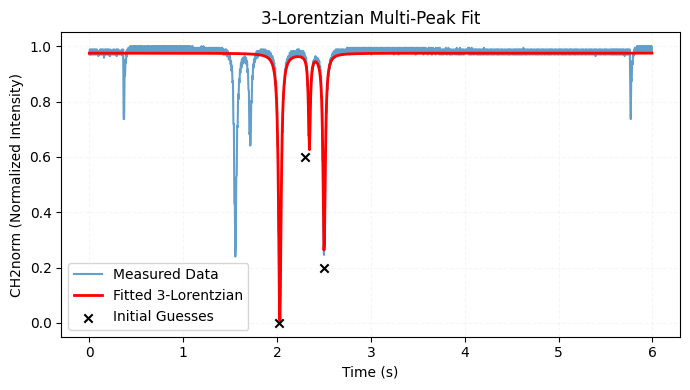

Lorentzian peak 1: 2.1808 ± 0.0012 | B-field: 1.8000e-05 ± 1.4400e-06
Lorentzian peak 2: 3.1231 ± 0.0010 | B-field: 2.8800e-05 ± 1.9200e-06
Lorentzian peak 3: 2.8085 ± 0.0019 | B-field: 2.5200e-05 ± 1.4400e-06


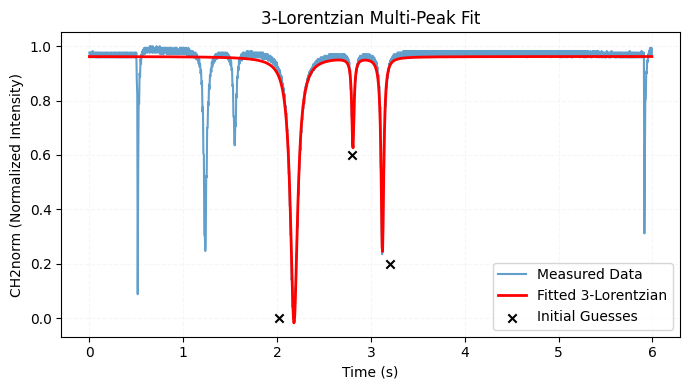

Lorentzian peak 1: 2.1669 ± 0.0015 | B-field: 1.8000e-05 ± 1.4400e-06
Lorentzian peak 2: 3.5827 ± 0.0011 | B-field: 3.3360e-05 ± 1.4400e-06
Lorentzian peak 3: 3.1096 ± 0.0022 | B-field: 2.8560e-05 ± 1.4400e-06


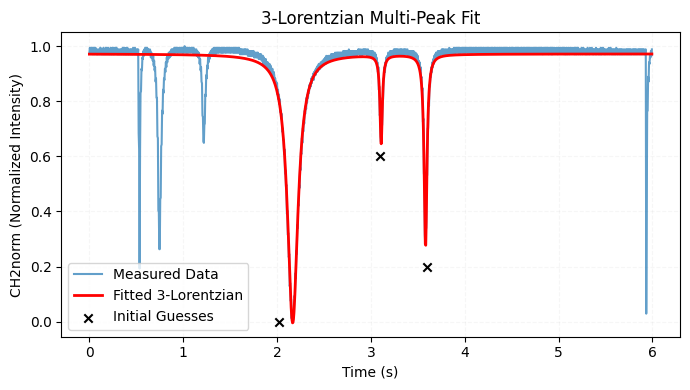

Lorentzian peak 1: 2.1746 ± 0.0011 | B-field: 1.8000e-05 ± 1.4400e-06
Lorentzian peak 2: 4.0634 ± 0.0010 | B-field: 3.8880e-05 ± 1.9200e-06
Lorentzian peak 3: 3.4342 ± 0.0019 | B-field: 3.2400e-05 ± 1.4400e-06


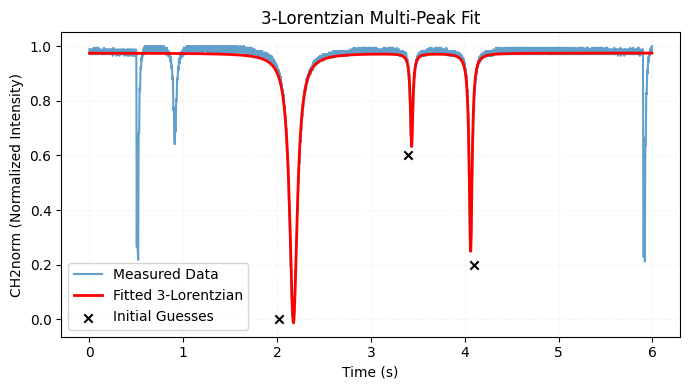

Lorentzian peak 1: 2.1610 ± 0.0014 | B-field: 1.8000e-05 ± 1.4400e-06
Lorentzian peak 2: 4.5223 ± 0.0011 | B-field: 4.3680e-05 ± 1.9200e-06
Lorentzian peak 3: 3.7356 ± 0.0021 | B-field: 3.4080e-05 ± 1.9200e-06


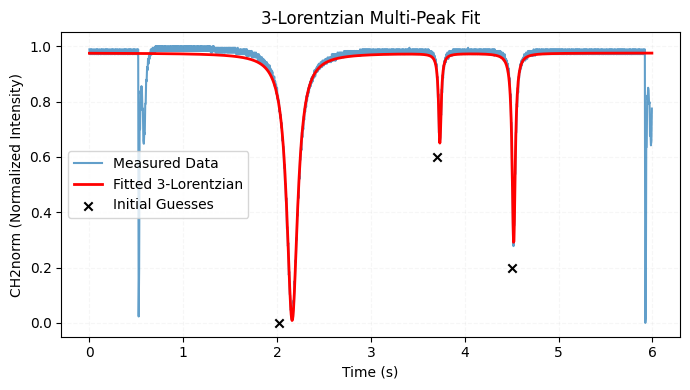

Lorentzian peak 1: 2.1777 ± 0.0008 | B-field: 1.8720e-05 ± 1.9200e-06
Lorentzian peak 2: 5.0126 ± 0.0007 | B-field: 4.9440e-05 ± 1.9200e-06
Lorentzian peak 3: 4.0688 ± 0.0014 | B-field: 3.8640e-05 ± 1.4400e-06


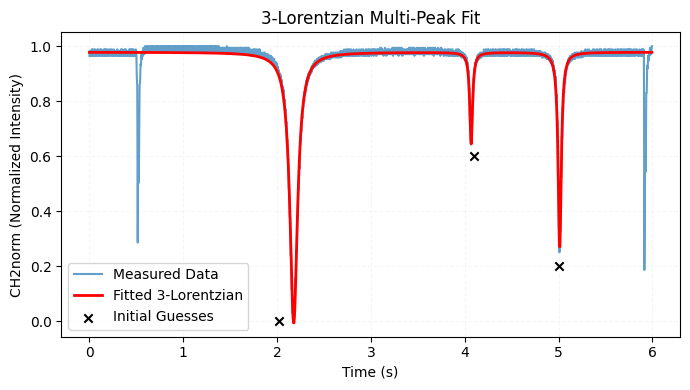

Lorentzian peak 1: 2.1726 ± 0.0010 | B-field: 1.8000e-05 ± 1.4400e-06
Lorentzian peak 2: 5.4793 ± 0.0010 | B-field: 5.5200e-05 ± 1.9200e-06
Lorentzian peak 3: 4.3788 ± 0.0020 | B-field: 4.3200e-05 ± 1.9200e-06


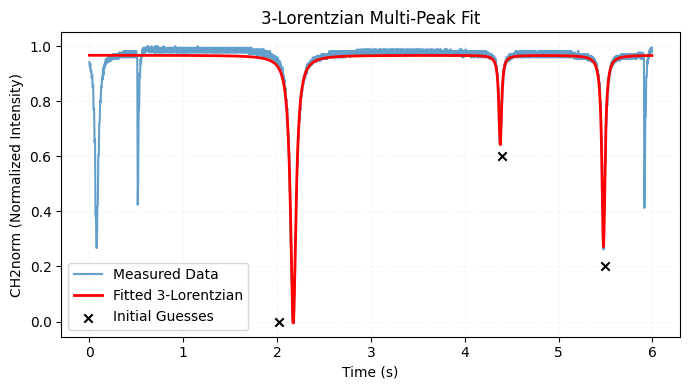

Lorentzian peak 1: 2.0287 ± 0.0006 | B-field: 1.8720e-05 ± 1.9200e-06
Lorentzian peak 2: 5.7129 ± 0.0009 | B-field: 5.8560e-05 ± 1.9200e-06
Lorentzian peak 3: 4.4885 ± 0.0018 | B-field: 4.6080e-05 ± 1.9200e-06


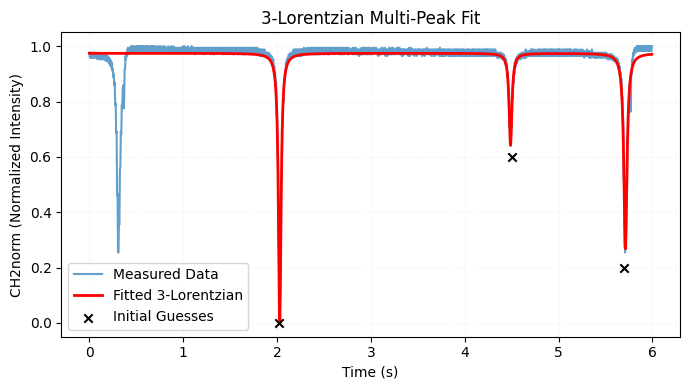

In [607]:
for p0, df_ in zip(p0guesses, df):
    fit_lorentzians(df_,p0,3,lopt)

In [608]:
freq_list = [25,50,75,100,125,150,175,195]
lopt = np.array(lopt)
# Add freq_list as first column
lopt = np.column_stack((freq_list, lopt))

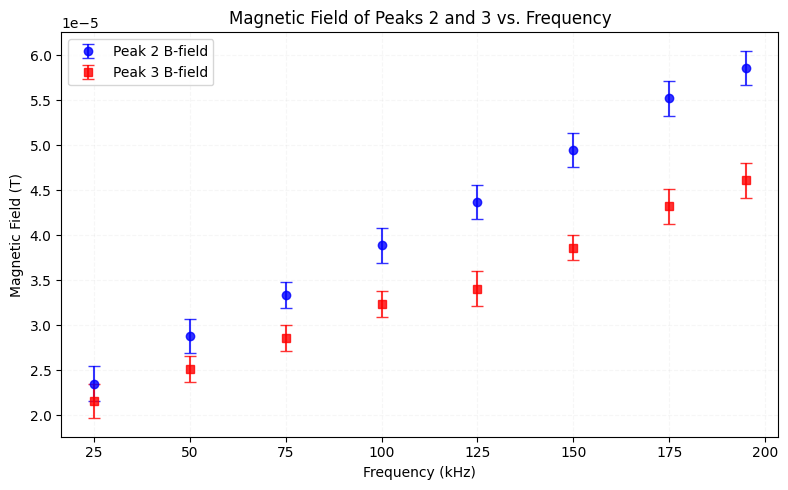

In [609]:
freq = lopt[:, 0]
mean_b2, unc_b2 = lopt[:, 2], lopt[:, 5]
mean_b3, unc_b3 = lopt[:, 3], lopt[:, 6]

plt.figure(figsize=(8, 5))

plt.errorbar(freq, mean_b2, yerr=unc_b2, fmt='o', color='blue', 
             capsize=4, elinewidth=1.5, alpha=0.8, label='Peak 2 B-field')

plt.errorbar(freq, mean_b3, yerr=unc_b3, fmt='s', color='red', 
             capsize=4, elinewidth=1.5, alpha=0.8, label='Peak 3 B-field')

plt.xlabel('Frequency (kHz)')
plt.ylabel('Magnetic Field (T)')
plt.title('Magnetic Field of Peaks 2 and 3 vs. Frequency')
plt.grid(True, linestyle='--', alpha=0.1)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

<>:42: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:44: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:42: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:44: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
C:\Users\imath\AppData\Local\Temp\ipykernel_32616\3762542525.py:42: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  f'$\chi^2_\\nu$ = {red_chi2_2:.2f}')
C:\Users\imath\AppData\Local\Temp\ipykernel_32616\3762542525.py:44: SyntaxWarning: "\c" is an invalid escape sequence. Such sequen

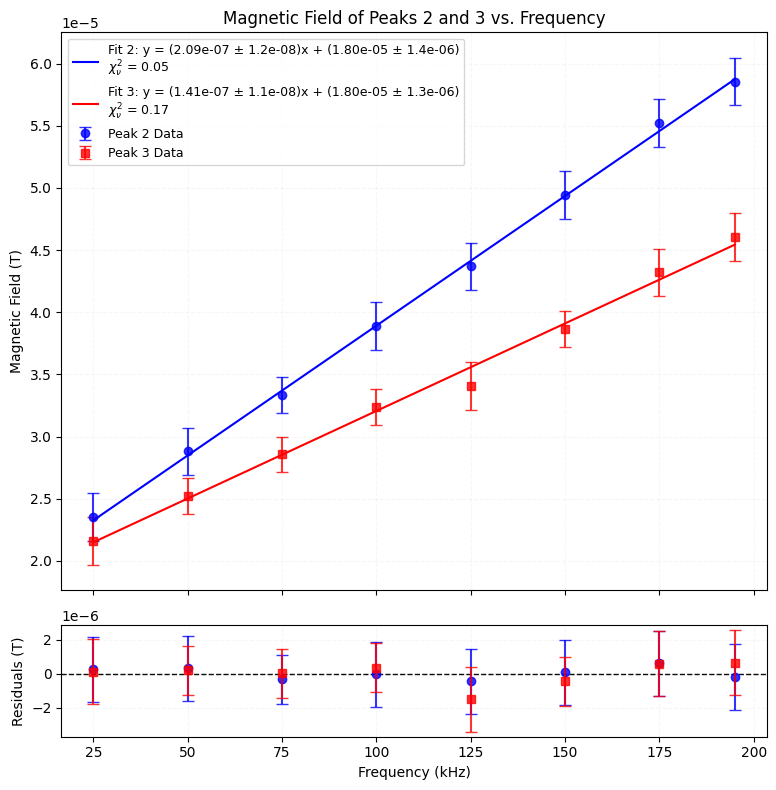

In [610]:
def linear_model(x, m, b):
    return m * x + b

# Extract data using the index mapping
freq = lopt[:, 0]
mean_b2, unc_b2 = lopt[:, 2], lopt[:, 5]
mean_b3, unc_b3 = lopt[:, 3], lopt[:, 6]

# Perform weighted linear fits (sigma accounts for the uncertainties)
popt2, pcov2 = curve_fit(linear_model, freq, mean_b2, sigma=unc_b2, absolute_sigma=True)
popt3, pcov3 = curve_fit(linear_model, freq, mean_b3, sigma=unc_b3, absolute_sigma=True)

# Calculate parameter uncertainties
err2 = np.sqrt(np.diag(pcov2))
err3 = np.sqrt(np.diag(pcov3))

# Calculate residuals (Observed - Fitted)
res2 = mean_b2 - linear_model(freq, *popt2)
res3 = mean_b3 - linear_model(freq, *popt3)

# Calculate Chi-Squared and Reduced Chi-Squared
dof = len(freq) - 2  # Degrees of freedom: N points - 2 parameters (linear)

chi2_2 = np.sum((res2 / unc_b2)**2)
red_chi2_2 = chi2_2 / dof

chi2_3 = np.sum((res3 / unc_b3)**2)
red_chi2_3 = chi2_3 / dof

# Initialize figure. height_ratios changed from [3, 1] to [5, 1] to shrink residuals plot.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), gridspec_kw={'height_ratios': [5, 1]}, sharex=True)

# --- Top Subplot: Main Data and Fits ---
ax1.errorbar(freq, mean_b2, yerr=unc_b2, fmt='o', color='blue', capsize=4, alpha=0.8, label='Peak 2 Data')
ax1.errorbar(freq, mean_b3, yerr=unc_b3, fmt='s', color='red', capsize=4, alpha=0.8, label='Peak 3 Data')

# Generate smooth line for fits
freq_fit = np.linspace(min(freq), max(freq), 100)

# Format parameter labels to include Reduced Chi-Squared
fit_label2 = (f'Fit 2: y = ({popt2[0]:.2e} ± {err2[0]:.1e})x + ({popt2[1]:.2e} ± {err2[1]:.1e})\n'
              f'$\chi^2_\\nu$ = {red_chi2_2:.2f}')
fit_label3 = (f'Fit 3: y = ({popt3[0]:.2e} ± {err3[0]:.1e})x + ({popt3[1]:.2e} ± {err3[1]:.1e})\n'
              f'$\chi^2_\\nu$ = {red_chi2_3:.2f}')

ax1.plot(freq_fit, linear_model(freq_fit, *popt2), 'b-', linewidth=1.5, label=fit_label2)
ax1.plot(freq_fit, linear_model(freq_fit, *popt3), 'r-', linewidth=1.5, label=fit_label3)

ax1.set_ylabel('Magnetic Field (T)')
ax1.set_title('Magnetic Field of Peaks 2 and 3 vs. Frequency')
ax1.grid(True, linestyle='--', alpha=0.1)
ax1.legend(loc='best', fontsize=9)

# --- Bottom Subplot: Residuals ---
ax2.axhline(0, color='black', linestyle='--', linewidth=1, zorder=1)
ax2.errorbar(freq, res2, yerr=unc_b2, fmt='o', color='blue', capsize=4, alpha=0.8, zorder=2)
ax2.errorbar(freq, res3, yerr=unc_b3, fmt='s', color='red', capsize=4, alpha=0.8, zorder=3)

ax2.set_xlabel('Frequency (kHz)')
ax2.set_ylabel('Residuals (T)')
ax2.grid(True, linestyle='--', alpha=0.1)

plt.tight_layout()
plt.show()

#### Now Entering the quadratic regime

What I am going to have to do is caliberate the voltage reading of the offset magnetic field to the voltage reading we took and add it to the whole magnetic field value as offset.

In [611]:
# Converting the sweep values to b field values:
def add_magnetic_field(filename):
    ItB = (0.6*1e-4)#Teslas
    header_info = pd.read_csv(filename, skiprows=1, nrows=1, header=None)
    timeconst = float(header_info.iloc[0, 4])
    df = pd.read_csv(filename, skiprows=2, usecols=[0, 1, 2], names=["Sequence", "CH1", "CH2"])
    df["Bfield"] = (df["CH1"]*ItB)
    df["CH2norm"] = (df["CH2"] - min(df["CH2"]))/(max(df["CH2"])-min(df["CH2"]))
    df["time"] = df["Sequence"]*timeconst
    filename, ext = os.path.splitext(filename)
    new_filename = f"{filename}_B{ext}"
    df.to_csv(new_filename, index=False)
    print("New file:",new_filename) 
    return df

In [612]:
c1 = add_magnetic_field("offsetfieldcalliberation/c1-330kHz_0p1mV.csv")
c2 = add_magnetic_field("offsetfieldcalliberation/c2-330kHz_25p1mV.csv")
c3 = add_magnetic_field("offsetfieldcalliberation/c3-330kHz_49p5mV.csv")
c4 = add_magnetic_field("offsetfieldcalliberation/c4-330kHz_25p4mV.csv")
c5 = add_magnetic_field("offsetfieldcalliberation/c5-330kHz_25p4mV.csv")

New file: offsetfieldcalliberation/c1-330kHz_0p1mV_B.csv
New file: offsetfieldcalliberation/c2-330kHz_25p1mV_B.csv
New file: offsetfieldcalliberation/c3-330kHz_49p5mV_B.csv
New file: offsetfieldcalliberation/c4-330kHz_25p4mV_B.csv
New file: offsetfieldcalliberation/c5-330kHz_25p4mV_B.csv


Lorentzian peak 1: 1.5842 ± 0.0009 | B-field: 6.3600e-05 ± 1.2000e-06


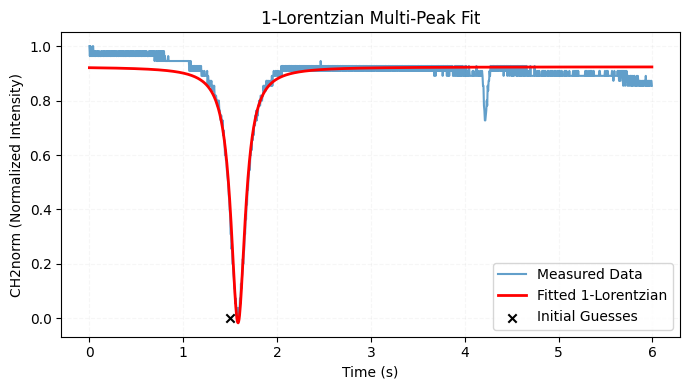

Lorentzian peak 1: 0.3555 ± 0.0016 | B-field: 2.0880e-05 ± 1.9200e-06
Lorentzian peak 2: 5.1611 ± 0.0008 | B-field: 4.3560e-05 ± 7.2000e-07


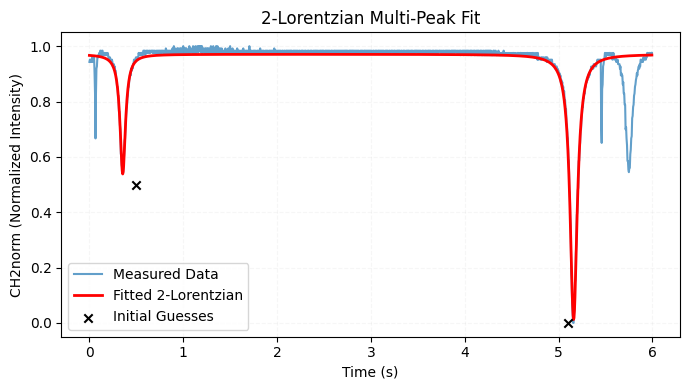

Lorentzian peak 1: 3.5459 ± 0.0007 | B-field: 3.0480e-06 ± 4.3200e-07


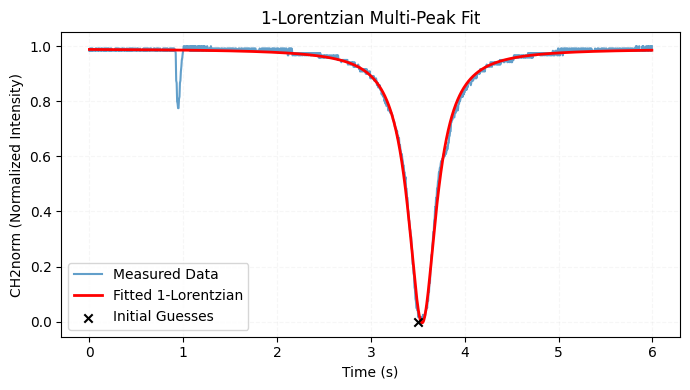

Lorentzian peak 1: 3.6319 ± 0.0004 | B-field: 4.3980e-05 ± 7.2000e-07


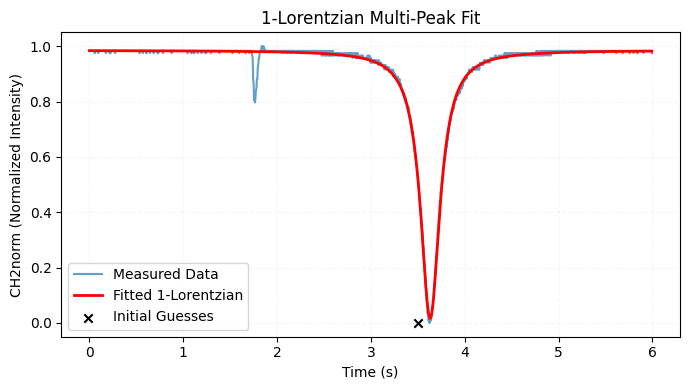

Lorentzian peak 1: 3.4707 ± 0.0009 | B-field: 2.0970e-05 ± 5.4000e-07


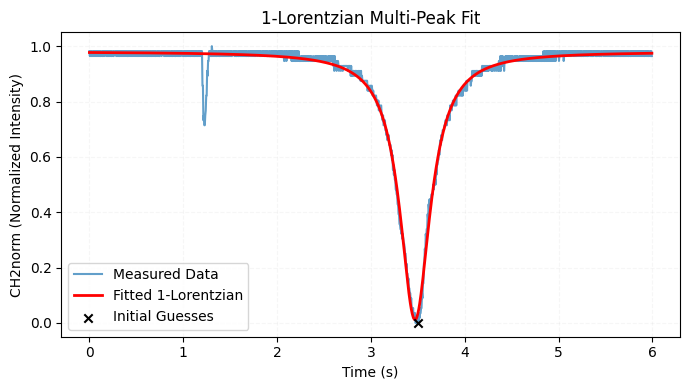

[[np.float64(6.36e-05), np.float64(1.200000000000002e-06)], [np.float64(3.0480000000000003e-06), np.float64(4.3199999999999984e-07)], [np.float64(4.3979999999999996e-05), np.float64(7.199999999999999e-07)], [np.float64(2.0969999999999997e-05), np.float64(5.400000000000016e-07)]]


In [613]:
copt = []
fit_lorentzians(c1,[1.0,0.0,1.5,0.001],1,copt)
fit_lorentzians(c2,[1.0,0.5,0.5,0.001,0.0,5.1,0.001],2)
fit_lorentzians(c3,[1.0,0.0,3.5,0.001],1,copt)
fit_lorentzians(c4,[1.0,0.0,3.5,0.001],1,copt)
fit_lorentzians(c5,[1.0,0.0,3.5,0.001],1,copt)
print(copt)

In [614]:
copt = np.array(copt)
diff = copt[2]-copt[3]
p1 = copt[0] + diff
p2 = copt[1]
VtB = (p1-p2)/49.5

In [615]:
# Converting the sweep values to b field values:
def add_magnetic_field_woff(filename,voltage):
    ItB = (0.6*1e-4)#Teslas
    header_info = pd.read_csv(filename, skiprows=1, nrows=1, header=None)
    timeconst = float(header_info.iloc[0, 4])
    df = pd.read_csv(filename, skiprows=2, usecols=[0, 1, 2], names=["Sequence", "CH1", "CH2"])
    df["Bfield"] = (df["CH1"]*ItB)
    df["Bfield"] = df["Bfield"] + (VtB[0]*voltage)
    df["CH2norm"] = (df["CH2"] - min(df["CH2"]))/(max(df["CH2"])-min(df["CH2"]))
    df["time"] = df["Sequence"]*timeconst
    filename, ext = os.path.splitext(filename)
    new_filename = f"{filename}_B{ext}"
    df.to_csv(new_filename, index=False)
    print("New file:",new_filename) 
    return df

In [616]:
df_300 = add_magnetic_field_woff("linear_zeeman_data/300kHz_5s.csv",20)
df_400 = add_magnetic_field_woff("linear_zeeman_data/400kHz_33p36mV.csv",33.36)
df_500 = add_magnetic_field_woff("linear_zeeman_data/500kHz_5s.csv",42)
df_600 = add_magnetic_field_woff("linear_zeeman_data/600kHz_5s.csv",55)
df_doub = [df_300,df_400,df_500,df_600]

New file: linear_zeeman_data/300kHz_5s_B.csv
New file: linear_zeeman_data/400kHz_33p36mV_B.csv
New file: linear_zeeman_data/500kHz_5s_B.csv
New file: linear_zeeman_data/600kHz_5s_B.csv


Lorentzian peak 1: 2.4573 ± 0.0003 | B-field: 5.8962e-05 ± 1.9200e-06
Lorentzian peak 2: 4.3435 ± 0.0002 | B-field: 7.8762e-05 ± 1.2000e-06


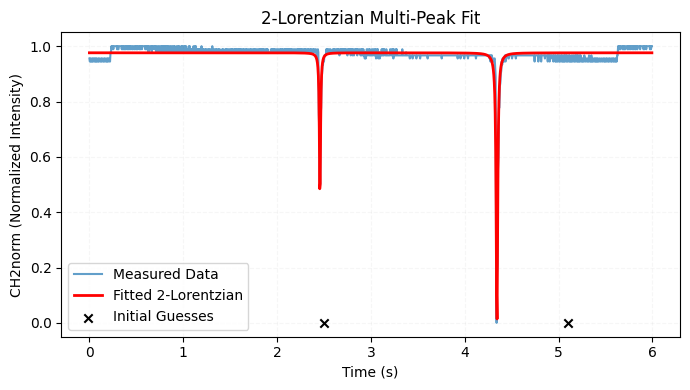

Lorentzian peak 1: 1.4555 ± 0.0008 | B-field: 7.3596e-05 ± 4.8000e-07
Lorentzian peak 2: 4.7818 ± 0.0004 | B-field: 1.0108e-04 ± 7.2000e-07


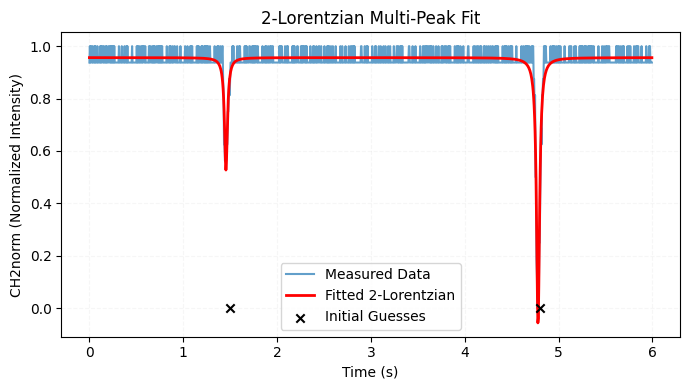

Lorentzian peak 1: 1.3143 ± 0.0003 | B-field: 8.2301e-05 ± 1.2000e-06
Lorentzian peak 2: 4.6008 ± 0.0002 | B-field: 1.1830e-04 ± 1.2000e-06


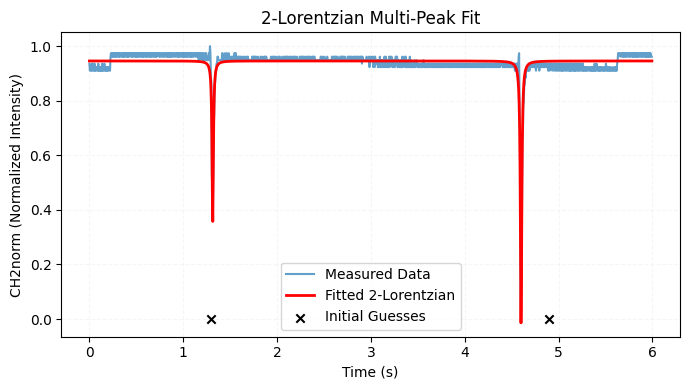

Lorentzian peak 1: 0.7512 ± 0.0002 | B-field: 9.8247e-05 ± 1.2000e-06
Lorentzian peak 2: 4.5623 ± 0.0003 | B-field: 1.4025e-04 ± 1.2000e-06


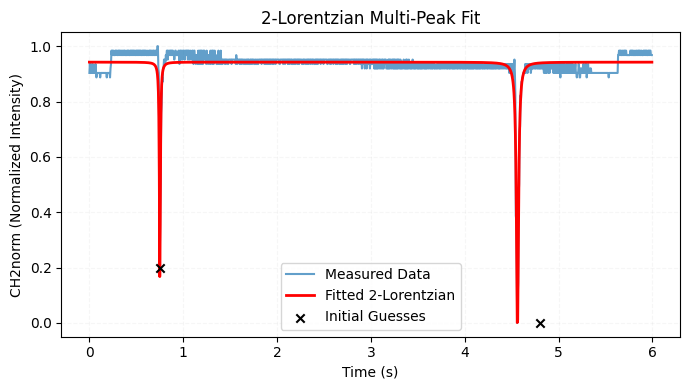

In [617]:
lopt2 = []
p0gues0 = [[1.0,0.0,2.5,0.001,0.0,5.1,0.001],
           [1.0,0.0,1.5,0.001,0.0,4.8,0.001],
           [1.0,0.0,1.3,0.001,0.0,4.9,0.001],
           [1.0,0.2,0.75,0.001,0.0,4.8,0.001]]

for p0,df_ in zip(p0gues0,df_doub):
    fit_lorentzians(df_,p0,2,lopt2)

In [618]:
loptk = lopt[:, [0, 2, 3, 5, 6]]

lopt2 = np.array(lopt2, ndmin=2)
lopt2[:, [0, 1]] = lopt2[:, [1, 0]]

freq_list2 = np.array([300, 400, 500, 600])
lopt2 = np.column_stack((freq_list2, lopt2))

loptk = np.vstack((loptk, lopt2))
print(lopt2)
print(loptk)

[[3.00000000e+02 7.87624242e-05 5.89624242e-05 1.92000000e-06
  1.20000000e-06]
 [4.00000000e+02 1.01075724e-04 7.35957236e-05 4.80000000e-07
  7.20000000e-07]
 [5.00000000e+02 1.18301091e-04 8.23010909e-05 1.20000000e-06
  1.20000000e-06]
 [6.00000000e+02 1.40246667e-04 9.82466667e-05 1.20000000e-06
  1.20000000e-06]]
[[2.50000000e+01 2.35200000e-05 2.16000000e-05 1.92000000e-06
  1.92000000e-06]
 [5.00000000e+01 2.88000000e-05 2.52000000e-05 1.92000000e-06
  1.44000000e-06]
 [7.50000000e+01 3.33600000e-05 2.85600000e-05 1.44000000e-06
  1.44000000e-06]
 [1.00000000e+02 3.88800000e-05 3.24000000e-05 1.92000000e-06
  1.44000000e-06]
 [1.25000000e+02 4.36800000e-05 3.40800000e-05 1.92000000e-06
  1.92000000e-06]
 [1.50000000e+02 4.94400000e-05 3.86400000e-05 1.92000000e-06
  1.44000000e-06]
 [1.75000000e+02 5.52000000e-05 4.32000000e-05 1.92000000e-06
  1.92000000e-06]
 [1.95000000e+02 5.85600000e-05 4.60800000e-05 1.92000000e-06
  1.92000000e-06]
 [3.00000000e+02 7.87624242e-05 5.89624

<>:20: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:20: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
C:\Users\imath\AppData\Local\Temp\ipykernel_32616\1878553981.py:20: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  f'$\chi^2_\\nu$ = {red_chi2:.2f}')


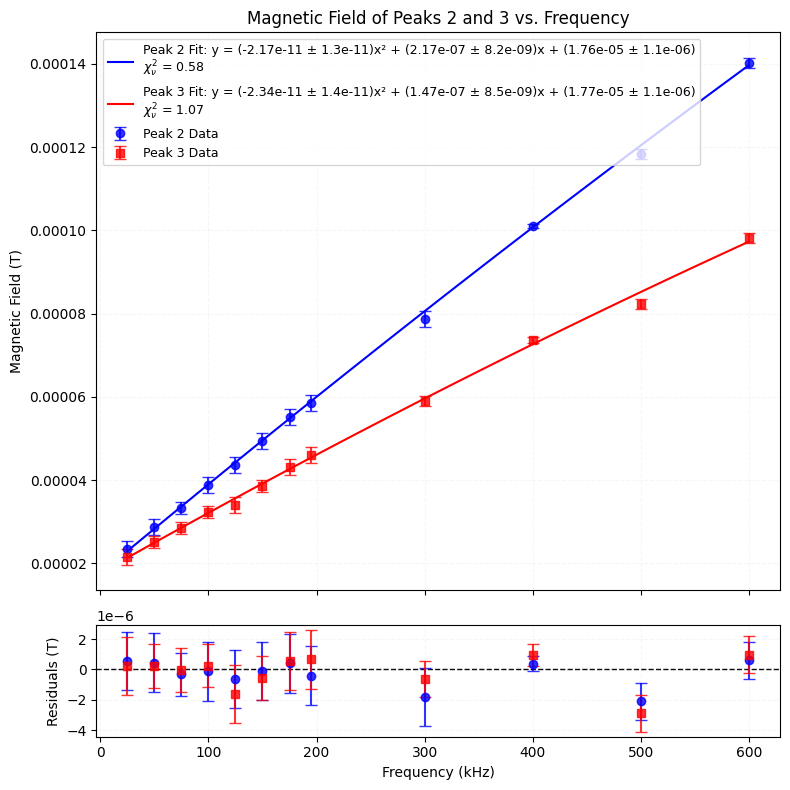

In [626]:
def quad_model(x, a, b, c):
    return a * x**2 + b * x + c

freq = loptk[:, 0]
freq_fit = np.linspace(freq.min(), freq.max(), 100)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), gridspec_kw={'height_ratios': [5, 1]}, sharex=True)
ax2.axhline(0, color='black', linestyle='--', linewidth=1, zorder=1)

# Loop handles Peak 2 (idx 1, 3) and Peak 3 (idx 2, 4) to eliminate code duplication
for m_idx, u_idx, color, fmt, name in [(1, 3, 'blue', 'o', 'Peak 2'), (2, 4, 'red', 's', 'Peak 3')]:
    mean_b, unc_b = loptk[:, m_idx], loptk[:, u_idx]
    
    popt, pcov = curve_fit(quad_model, freq, mean_b, sigma=unc_b, absolute_sigma=True)
    err = np.sqrt(np.diag(pcov))
    res = mean_b - quad_model(freq, *popt)
    red_chi2 = np.sum((res / unc_b)**2) / (len(freq) - 3)
    
    fit_lbl = (f'{name} Fit: y = ({popt[0]:.2e} ± {err[0]:.1e})x² + ({popt[1]:.2e} ± {err[1]:.1e})x + ({popt[2]:.2e} ± {err[2]:.1e})\n'
               f'$\chi^2_\\nu$ = {red_chi2:.2f}')
    
    ax1.errorbar(freq, mean_b, yerr=unc_b, fmt=fmt, color=color, capsize=4, alpha=0.8, label=f'{name} Data')
    ax1.plot(freq_fit, quad_model(freq_fit, *popt), color=color, linestyle='-', linewidth=1.5, label=fit_lbl)
    ax2.errorbar(freq, res, yerr=unc_b, fmt=fmt, color=color, capsize=4, alpha=0.8, zorder=2)

ax1.set_ylabel('Magnetic Field (T)')
ax1.set_title('Magnetic Field of Peaks 2 and 3 vs. Frequency')
ax1.grid(True, linestyle='--', alpha=0.1)
ax1.legend(loc='best', fontsize=9)

ax2.set_xlabel('Frequency (kHz)')
ax2.set_ylabel('Residuals (T)')
ax2.grid(True, linestyle='--', alpha=0.1)

plt.tight_layout()
plt.show()

In [620]:
df_9p02MHz = add_magnetic_field_woff("New Quadratic zeeman data/NewFile1.csv",1116)
df_7p75MHz = add_magnetic_field_woff("New Quadratic zeeman data/NewFile2.csv",960)
df_6p9MHz = add_magnetic_field_woff("New Quadratic zeeman data/NewFile3.csv",856.7)
df_5p3MHz = add_magnetic_field_woff("New Quadratic zeeman data/NewFile4.csv",659.7)
df_4p3MHz = add_magnetic_field_woff("New Quadratic zeeman data/NewFile5.csv",540.8)
df_2p9MHz = add_magnetic_field_woff("New Quadratic zeeman data/NewFile6.csv",362)
df_1p75MHz = add_magnetic_field_woff("New Quadratic zeeman data/NewFile7.csv",207.6)
df_800kHz = add_magnetic_field_woff("New Quadratic zeeman data/NewFile8.csv",94.9)
df_500kHz = add_magnetic_field_woff("New Quadratic zeeman data/NewFile9.csv",23.5)
df_300kHz = add_magnetic_field_woff("New Quadratic zeeman data/NewFile10.csv",25.9)

New file: New Quadratic zeeman data/NewFile1_B.csv
New file: New Quadratic zeeman data/NewFile2_B.csv
New file: New Quadratic zeeman data/NewFile3_B.csv
New file: New Quadratic zeeman data/NewFile4_B.csv
New file: New Quadratic zeeman data/NewFile5_B.csv
New file: New Quadratic zeeman data/NewFile6_B.csv
New file: New Quadratic zeeman data/NewFile7_B.csv
New file: New Quadratic zeeman data/NewFile8_B.csv
New file: New Quadratic zeeman data/NewFile9_B.csv
New file: New Quadratic zeeman data/NewFile10_B.csv


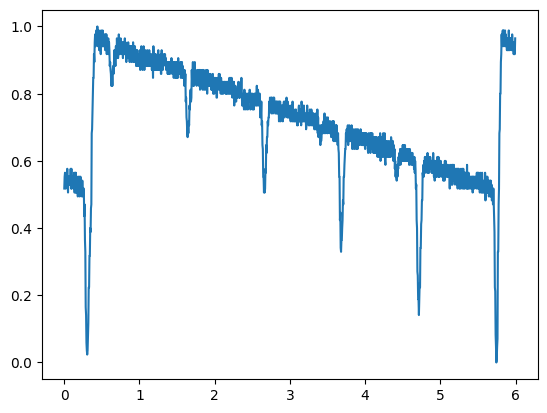

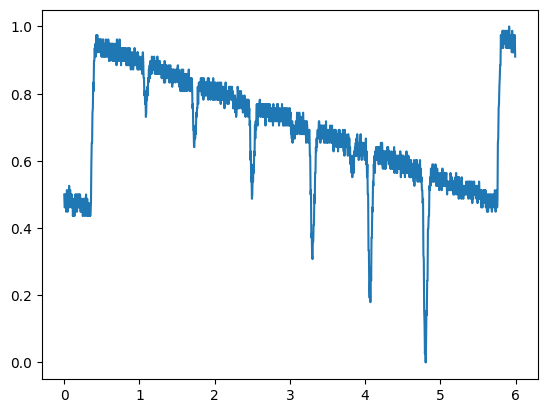

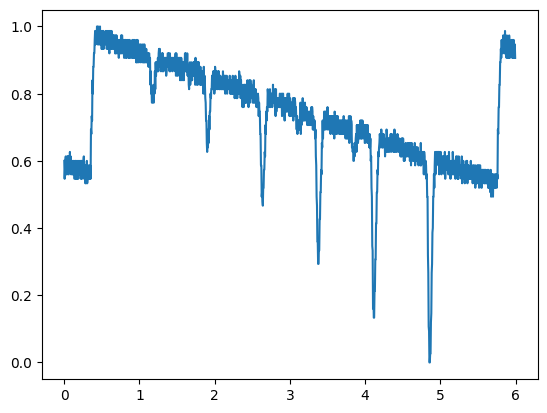

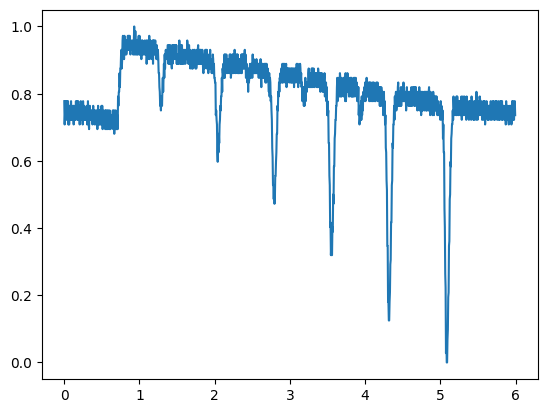

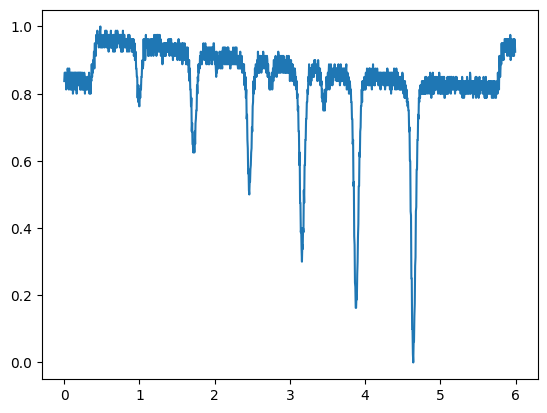

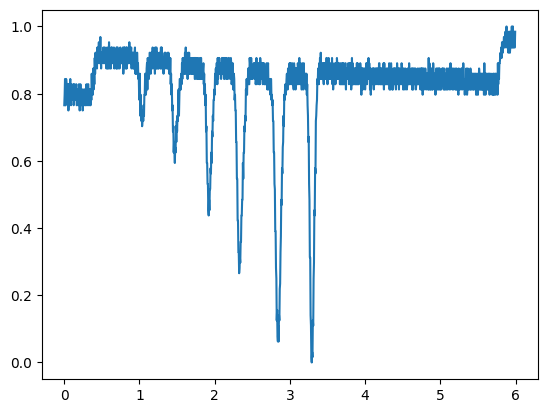

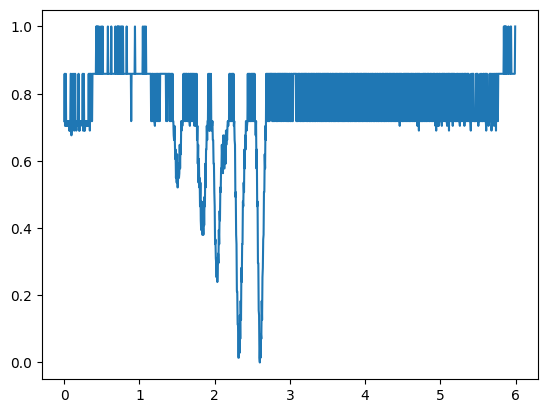

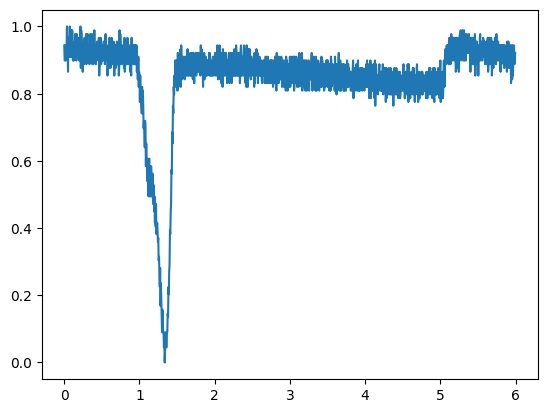

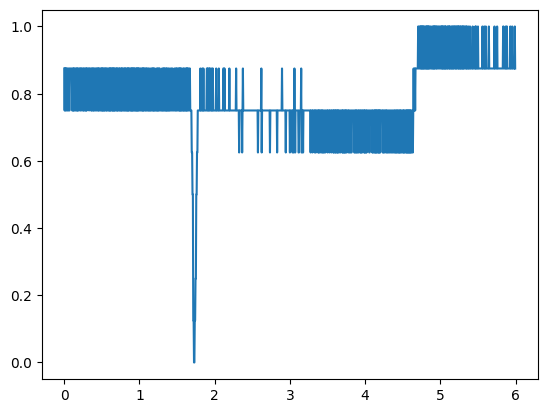

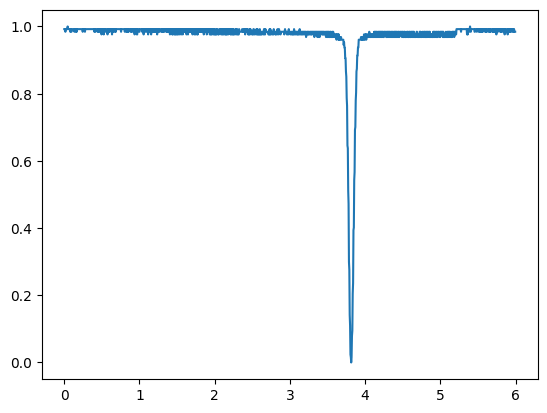

In [625]:
plt.plot(df_9p02MHz["time"],df_9p02MHz["CH2norm"])
plt.show()
plt.plot(df_7p75MHz["time"],df_7p75MHz["CH2norm"])
plt.show()
plt.plot(df_6p9MHz["time"], df_6p9MHz["CH2norm"])
plt.show()
plt.plot(df_5p3MHz["time"], df_5p3MHz["CH2norm"])
plt.show()
plt.plot(df_4p3MHz["time"], df_4p3MHz["CH2norm"])
plt.show()
plt.plot(df_2p9MHz["time"], df_2p9MHz["CH2norm"])
plt.show()
plt.plot(df_1p75MHz["time"],df_1p75MHz["CH2norm"])
plt.show()
plt.plot(df_800kHz["time"], df_800kHz["CH2norm"])
plt.show()
plt.plot(df_500kHz["time"], df_500kHz["CH2norm"])
plt.show()
plt.plot(df_300kHz["time"], df_300kHz["CH2norm"])
plt.show()

TypeError: object of type 'numpy.float64' has no len()